In [ ]:
#激活函数
# 统一部分
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline  
import numpy as np
import sklearn
import pandas as pd
import os
import sys
import time
from tqdm.auto import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

print(sys.version_info)
    
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print(device)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,))
])

train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)

print(len(train_dataset))
print(len(test_dataset))

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(class_names)
print(len(class_names))

batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False,num_workers=4)

sys.version_info(major=3, minor=13, micro=5, releaselevel='final', serial=0)
cuda:0
60000
10000
['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
10


In [3]:
#DNN建立

import torch.nn as nn
import torch.nn.functional as F

class DNN(nn.Module):
    def __init__(self, input_size = 784, hidden_size = 256, output_size = 10, num_hidden_layers = 19, num_classes = 10):
        super(DNN, self).__init__()

        # 初始化
        self.linear_relu_stack = nn.Sequential()
        
        #第一隐藏层
        self.linear_relu_stack.add_module("linear_0",nn.Linear(input_size, hidden_size))
        self.linear_relu_stack.add_module("bn_0",nn.BatchNorm1d(hidden_size))
        self.linear_relu_stack.add_module("relu_0",nn.ReLU())
    
        # 隐藏层
        for i in range(1, num_hidden_layers):
            self.linear_relu_stack.add_module(f"linear_{i}",nn.Linear(hidden_size, hidden_size))
            self.linear_relu_stack.add_module(f"bn_{i}",nn.BatchNorm1d(hidden_size))
            self.linear_relu_stack.add_module(f"relu_{i}",nn.ReLU())
        
        # 输出层
        self.linear_relu_stack.add_module("linear_out",nn.Linear(hidden_size, num_classes))
        
    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.linear_relu_stack(x)
        return x
    
model = DNN(input_size = 784, hidden_size = 256, output_size = 10, num_hidden_layers = 19, num_classes = 10)

print(model)
print(sum(p.numel() for p in model.parameters()))

DNN(
  (linear_relu_stack): Sequential(
    (linear_0): Linear(in_features=784, out_features=256, bias=True)
    (bn_0): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu_0): ReLU()
    (linear_1): Linear(in_features=256, out_features=256, bias=True)
    (bn_1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu_1): ReLU()
    (linear_2): Linear(in_features=256, out_features=256, bias=True)
    (bn_2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu_2): ReLU()
    (linear_3): Linear(in_features=256, out_features=256, bias=True)
    (bn_3): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu_3): ReLU()
    (linear_4): Linear(in_features=256, out_features=256, bias=True)
    (bn_4): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu_4): ReLU()
    (linear_5): Linear(in_features=256, out_f

In [4]:
batch_size = 64
input_tensor = torch.randn(batch_size, 1, 28, 28)

print(input_tensor.shape)

with torch.no_grad():
    output = model(input_tensor)

print(output.shape)

assert output.shape == (batch_size, 10), f"期望输出形状为 ({batch_size}, 10), 但得到 {output.shape}"
print("测试通过")

for batch in train_loader:
    inputs, targets = batch
    print(inputs.shape)
    print(targets.shape)
    break




torch.Size([64, 1, 28, 28])
torch.Size([64, 10])
测试通过
torch.Size([64, 1, 28, 28])
torch.Size([64])


In [ ]:
from my_trainer_for_t1 import Trainer

device = torch.device("cuda")
print(f"使用设备: {device}")

criterion = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

early_stopping_kwargs = {
    'patience': 10,
    'min_delta': 0.001,
    'mode': 'max'
}

trainer = Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    eval_step=500,
    early_stopping_kwargs=early_stopping_kwargs
)

trainer.train(num_epochs=20)

使用设备: cuda
[Step 500] Val Loss: 0.2597 Val Acc: 0.9390
Epoch [1/20]  Train Loss: 0.8181  Train Acc: 0.7352
[Step 1000] Val Loss: 0.4493 Val Acc: 0.8852
[Step 1500] Val Loss: 1.0001 Val Acc: 0.6779
Epoch [2/20]  Train Loss: 1.1375  Train Acc: 0.6147
[Step 2000] Val Loss: 0.4198 Val Acc: 0.8961
[Step 2500] Val Loss: 0.6135 Val Acc: 0.8329
Epoch [3/20]  Train Loss: 0.7337  Train Acc: 0.7806
[Step 3000] Val Loss: 0.3600 Val Acc: 0.9187
[Step 3500] Val Loss: 0.4795 Val Acc: 0.8827
Epoch [4/20]  Train Loss: 0.5330  Train Acc: 0.8551
[Step 4000] Val Loss: 0.3311 Val Acc: 0.9269
[Step 4500] Val Loss: 0.3488 Val Acc: 0.9009
Epoch [5/20]  Train Loss: 0.4531  Train Acc: 0.8842
[Step 5000] Val Loss: 0.2462 Val Acc: 0.9446
[Step 5500] Val Loss: 0.2735 Val Acc: 0.9349
Epoch [6/20]  Train Loss: 0.3440  Train Acc: 0.9194
[Step 6000] Val Loss: 0.2639 Val Acc: 0.9354
[Step 6500] Val Loss: 0.2769 Val Acc: 0.9362
Epoch [7/20]  Train Loss: 0.3318  Train Acc: 0.9202
[Step 7000] Val Loss: 0.1839 Val Acc: 0.9

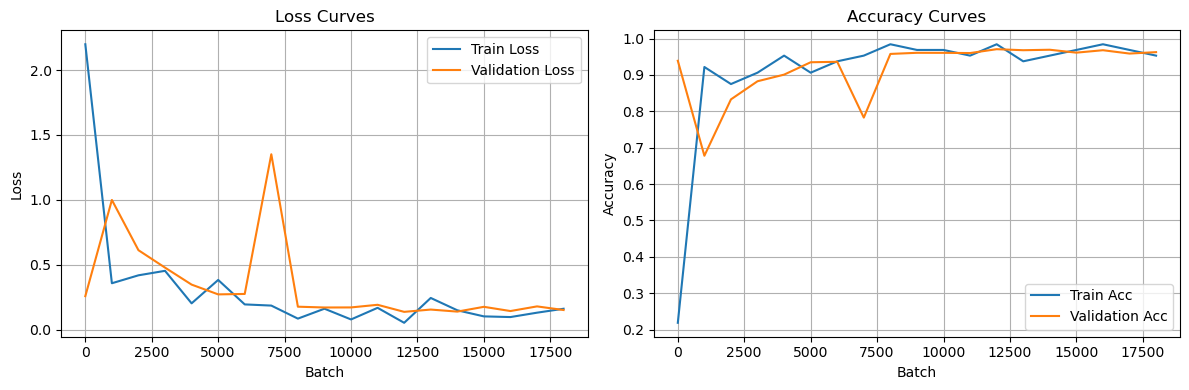

In [6]:
trainer.plot_curves()